In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
arabi_genes = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/rice_gene_results.csv', index_col= 0)
arabi_ortho = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/rice_ortho_trimmed_out_2_gene_families.csv', index_col= 0)
tomato_genes = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/maize_gene_results.csv', index_col= 0)
tomato_ortho = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/maize_ortho_trimmed_out_2_gene_families.csv', index_col= 0)

In [3]:
log_fc_change_evaluation_value = 1.5
log_fc_change_evaluation_value_negative = -1*log_fc_change_evaluation_value

In [4]:
tomato_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
10077at3193,29.545605,-3.303409,0.453894,-7.277930,3.389822e-13,1.872867e-12
10217at3193,94.418807,-0.871986,0.182575,-4.776044,1.787771e-06,5.446464e-06
105017at3193,25.128518,7.740641,1.351160,5.728886,1.010922e-08,3.922346e-08
10648at3193,790.240805,-0.817760,0.258080,-3.168629,1.531595e-03,3.196763e-03
10653at3193,231.999506,3.631205,0.213097,17.040173,4.135083e-65,1.255149e-63
...,...,...,...,...,...,...
97899at3193,123.885689,0.224134,0.203996,1.098720,2.718903e-01,3.451849e-01
9789at3193,259.250773,0.040918,0.138310,0.295841,7.673518e-01,8.149940e-01
9797at3193,65.311180,0.710791,0.212543,3.344229,8.251147e-04,1.795201e-03
9942at3193,932.655747,0.237622,0.086417,2.749720,5.964626e-03,1.119604e-02


In [5]:
trimmed_tomato_ortho = tomato_ortho.loc[tomato_ortho.index.isin(arabi_ortho.index)]
trimmed_arabi_ortho = arabi_ortho.loc[arabi_ortho.index.isin(trimmed_tomato_ortho.index)]


In [6]:
trimmed_arabi_ortho_named = trimmed_arabi_ortho.rename(columns = {'log2FoldChange':'Arabidopsis Log2FC'})
trimmed_tomato_ortho_named = trimmed_tomato_ortho.rename(columns = {'log2FoldChange':'Tomato Log2FC'})



In [7]:
merged_ortho_df = trimmed_arabi_ortho_named[['Arabidopsis Log2FC']].merge(right = trimmed_tomato_ortho_named, left_index= True, right_index = True)

In [8]:
merged_ortho_df

,Arabidopsis Log2FC,baseMean,Tomato Log2FC,lfcSE,stat,pvalue,padj
10653at3193,1.191514,231.999506,3.631205,0.213097,17.040173,4.135083e-65,1.255149e-63
10772at3193,0.004198,365.883842,-0.851444,0.140559,-6.057570,1.381932e-09,5.824944e-09
10787at3193,-1.430932,2154.235003,0.508823,0.108387,4.694496,2.672651e-06,7.978887e-06
10794at3193,-2.449515,24.001729,1.020467,0.319948,3.189475,1.425314e-03,2.983330e-03
10950at3193,0.863399,2767.645805,1.736015,0.075916,22.867596,9.766819e-116,5.342772e-114
...,...,...,...,...,...,...,...
9609at3193,0.352092,167.321996,0.959002,0.207176,4.628912,3.675917e-06,1.080208e-05
9789at3193,0.671112,259.250773,0.040918,0.138310,0.295841,7.673518e-01,8.149940e-01
9797at3193,0.464617,65.311180,0.710791,0.212543,3.344229,8.251147e-04,1.795201e-03
9942at3193,0.065816,932.655747,0.237622,0.086417,2.749720,5.964626e-03,1.119604e-02


In [9]:
log_fc_change_evaluation_value

1.5

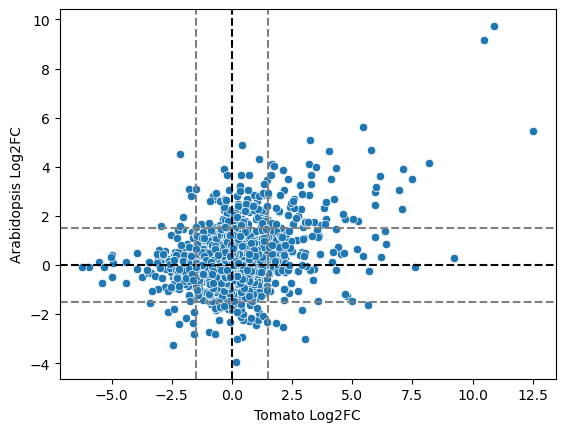

In [10]:
sns.scatterplot(data = merged_ortho_df, x ='Tomato Log2FC', y = 'Arabidopsis Log2FC' )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(x =log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(y =log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(x =log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(y =log_fc_change_evaluation_value_negative, color="grey", linestyle="--")

Text(0, 0.5, 'Orthogroup-wise log2-fold change in \n Sorghum Drought')

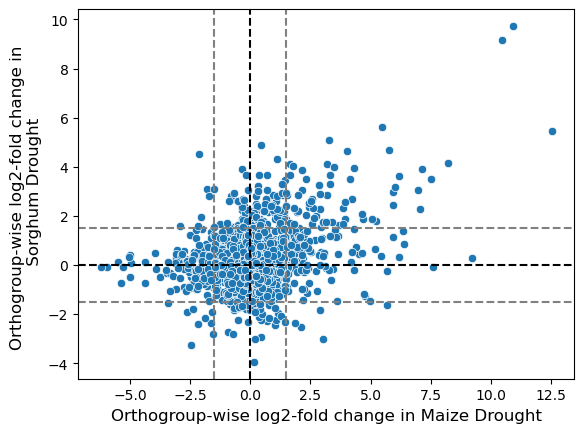

In [11]:
sns.scatterplot(x =trimmed_tomato_ortho['log2FoldChange'], y = trimmed_arabi_ortho['log2FoldChange'], )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.xlabel("Orthogroup-wise log2-fold change in Maize Drought", fontsize = 12)
plt.ylabel("Orthogroup-wise log2-fold change in \n Sorghum Drought", fontsize = 12)

In [12]:
trimmed_arabi_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
10653at3193,38.183282,1.191514,0.522798,2.279110,2.266050e-02,4.498493e-02
10772at3193,25.192556,0.004198,0.619886,0.006773,9.945964e-01,9.953931e-01
10787at3193,867.016981,-1.430932,0.136020,-10.519975,6.989217e-26,1.082462e-24
10794at3193,351.883200,-2.449515,0.242327,-10.108298,5.075848e-24,7.460501e-23
10950at3193,4315.100567,0.863399,0.094077,9.177561,4.409648e-20,5.265900e-19
...,...,...,...,...,...,...
9609at3193,336.380432,0.352092,0.199466,1.765172,7.753492e-02,1.310784e-01
9789at3193,468.891041,0.671112,0.163991,4.092379,4.269708e-05,1.498396e-04
9797at3193,164.587090,0.464617,0.268912,1.727767,8.403003e-02,1.398510e-01
9942at3193,1800.013453,0.065816,0.108469,0.606772,5.440021e-01,6.419773e-01


In [13]:
all(trimmed_arabi_ortho.index == trimmed_tomato_ortho.index)

True

In [14]:
merged_result = pd.DataFrame(data = zip(trimmed_tomato_ortho['log2FoldChange'], trimmed_arabi_ortho['log2FoldChange']), columns = ['Tomato','Arabi'])

all_over_1 = merged_result.loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)]
all_under_1 = merged_result.loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_bottom = merged_result.loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_top = merged_result.loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']>log_fc_change_evaluation_value)]

In [15]:
merged_result['Classification'] = 'Non-substantial'
merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']>log_fc_change_evaluation_value)]= 'Substantial'

/tmp/ipykernel_1190780/2994845458.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
/tmp/ipykernel_1190780/2994845458.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
/tmp/ipykernel_1190780/2994845458.py:4: SettingWithCopyWarning: 
A value is trying to be set on a cop

In [58]:
sns.scatterplot(data = merged_result.loc[merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 10)
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.title('Orthogroupwise Maize vs Sorghum \n 6.81 Concordant Genes per Discordant Gene')
plt.xlabel("Orthogroup-wise log2-fold change in Maize Drought", fontsize = 12)
plt.ylabel("Orthogroup-wise log2-fold change in Sorghum Drought", fontsize = 12)

KeyError: 'Classification'

In [17]:
discord_ratio = (len(all_over_1)+len(all_under_1))/(len(discord_bottom)+len(discord_top))
discord_ratio

6.818181818181818

In [18]:
discord_bottom

,Tomato,Arabi
74,2.908451,-1.817471
503,2.124884,-2.525126
1222,3.028913,-3.008050
1776,1.852609,-2.354628
2461,5.671827,-1.613667


In [19]:
discord_top

,Tomato,Arabi
141,-2.032977,1.972928
550,-2.930564,1.594899
1395,-2.138103,4.527144
1821,-1.776985,3.097453
2123,-1.699671,2.821731
2704,-2.163871,1.575800


In [20]:
merged_result = pd.DataFrame(data = zip(trimmed_tomato_ortho['log2FoldChange'], trimmed_arabi_ortho['log2FoldChange']), columns = ['Tomato','Arabi'])
pos_thresh = 1
neg_thresh = 1
tomato_any_change = merged_result.loc[(merged_result['Tomato']>pos_thresh)|(merged_result['Tomato']<neg_thresh)]
tomato_concordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']>pos_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']<neg_thresh))]
tomato_disconcordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']<neg_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']>pos_thresh))]
percent_concordant_tomato = len(tomato_concordant_change)/len(tomato_any_change)
percent_non_discord_tomato = len(tomato_concordant_change)/(len(tomato_concordant_change+tomato_disconcordant_change))
print(percent_concordant_tomato)
print(percent_non_discord_tomato)


arabi_any_change = merged_result.loc[(merged_result['Arabi']>pos_thresh)|(merged_result['Arabi']<neg_thresh)]
arabi_concordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']>pos_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']<neg_thresh))]
arabi_disconcordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']<neg_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']>pos_thresh))]

percent_concordant_arabi = len(arabi_concordant_change)/len(arabi_any_change)
percent_non_discord_arabi = len(arabi_concordant_change)/(len(arabi_concordant_change+arabi_disconcordant_change))

print(percent_concordant_arabi)
print(percent_non_discord_arabi)

0.8416605437178545
0.8416605437178545
0.8416605437178545
0.8416605437178545


In [21]:
arabi_disconcordant_change

,Tomato,Arabi
3,1.020467,-2.449515
4,1.736015,0.863399
8,0.251211,2.487463
20,0.756268,1.024955
24,1.440056,0.530539
...,...,...
2702,1.802194,0.164793
2704,-2.163871,1.575800
2706,1.229990,-0.302439
2712,0.326227,1.190800


In [22]:
tomato_any_change

,Tomato,Arabi
0,3.631205,1.191514
1,-0.851444,0.004198
2,0.508823,-1.430932
3,1.020467,-2.449515
4,1.736015,0.863399
...,...,...
2717,0.959002,0.352092
2718,0.040918,0.671112
2719,0.710791,0.464617
2720,0.237622,0.065816


In [23]:
tomato_concordant_change

,Tomato,Arabi
0,3.631205,1.191514
1,-0.851444,0.004198
2,0.508823,-1.430932
5,-1.872667,-0.004505
6,-0.736159,0.142496
...,...,...
2717,0.959002,0.352092
2718,0.040918,0.671112
2719,0.710791,0.464617
2720,0.237622,0.065816


In [41]:
arabidopsis_tomato_nm = pd.read_csv('/vault/transfer/passala/OrthoDB_data/V_11_pairwise_maps_fixed_problem_species/rice_jp_to_maize_ortholog_NM.csv')

In [42]:
arabidopsis_tomato_nm

,rice_jp OrthoGene,maize OrthoGene,Orthogroup,rice_jp Symbol,maize Symbol
0,39947_0:00057a,4577_0:00240a,10051at3193,LOC107276016,Zm00001d044385
1,39947_0:000a9c,4577_0:00240a,10051at3193,Os01g0596100,Zm00001d044385
2,39947_0:0016b5,4577_0:001563,10077at3193,LOC4329011,Zm00001d004486
3,39947_0:0016b5,4577_0:001cb5,10077at3193,LOC4329011,Zm00001d004506
4,39947_0:0033f9,4577_0:0002f4,10092at3193,Os05g0333200,Zm00001d027886
...,...,...,...,...,...
70305,39947_0:000ecd,4577_0:004be5,9959at3193,LOC4327414,LOC103625771
70306,39947_0:00280c,4577_0:004be5,9959at3193,LOC4334580,LOC103625771
70307,39947_0:000300,4577_0:006fa9,9959at3193,Os01g0834500,LOC101027156
70308,39947_0:000ecd,4577_0:006fa9,9959at3193,LOC4327414,LOC101027156


In [43]:
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'rice_jp Symbol',)
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'maize Symbol',)
arabidopsis_tomato_nm

,rice_jp OrthoGene,maize OrthoGene,Orthogroup,rice_jp Symbol,maize Symbol
0,39947_0:00057a,4577_0:00240a,10051at3193,LOC107276016,Zm00001d044385
2,39947_0:0016b5,4577_0:001563,10077at3193,LOC4329011,Zm00001d004486
4,39947_0:0033f9,4577_0:0002f4,10092at3193,Os05g0333200,Zm00001d027886
5,39947_0:0040ab,4577_0:0077eb,10107at3193,Os06g0212400,LOC100194120
7,39947_0:0050b1,4577_0:0082bb,1013at3193,LOC112939845,LOC109943179
...,...,...,...,...,...
70272,39947_0:000faa,4577_0:004266,9917at3193,LOC4329688,LOC100275271
70273,39947_0:00335b,4577_0:004f8e,9919at3193,Os05g0519500,Zm00001d038807
70274,39947_0:006f69,4577_0:00858d,99231at3193,OrsajCp105,ZemaCp102
70278,39947_0:0020d4,4577_0:0012b0,9942at3193,Os03g0277000,Zm00001d029596


In [44]:
arabi_genes_trimmed = arabi_genes.merge(how = 'inner', left_index= True, right = arabidopsis_tomato_nm[['maize Symbol','rice_jp Symbol']], right_on= 'rice_jp Symbol')
arabi_genes_trimmed = arabi_genes_trimmed.drop_duplicates(subset = 'rice_jp Symbol', keep = False)
arabi_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol,rice_jp Symbol
6455,1173.668182,-0.452103,0.132250,-3.418541,6.295781e-04,2.080418e-03,Zm00001d040234,Os01g0100100
17917,367.754989,0.446220,0.190792,2.338774,1.934712e-02,4.342247e-02,Zm00001d029189,Os01g0100600
39571,1313.645813,-0.097851,0.131237,-0.745600,4.559090e-01,5.794364e-01,Zm00001d037929,Os01g0100700
53344,2395.431575,-0.068746,0.117539,-0.584880,5.586285e-01,6.720552e-01,LOC100281847,Os01g0100900
9418,50.145130,-0.121051,0.450544,-0.268677,7.881783e-01,8.565717e-01,LOC100502008,Os01g0101300
...,...,...,...,...,...,...,...,...
10946,637.354476,0.626580,0.156505,4.003573,6.239290e-05,2.487483e-04,LOC100283028,Os12g0639100
23070,102.387838,-0.635634,0.342274,-1.857091,6.329817e-02,1.199935e-01,LOC103641011,Os12g0639800
28353,5241.230952,-0.340263,0.113528,-2.997182,2.724878e-03,7.774809e-03,Zm00001d033377,Os12g0640600
66788,3525.819092,0.748280,0.117151,6.387332,1.688044e-10,1.315701e-09,Zm00001d031232,Os12g0641100


In [45]:
tomato_genes_trimmed = tomato_genes.merge(how = 'inner', left_index= True, right = arabidopsis_tomato_nm[['maize Symbol','rice_jp Symbol']], right_on= 'maize Symbol')
tomato_genes_trimmed = tomato_genes_trimmed.drop_duplicates(subset = 'rice_jp Symbol', keep = False)
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol,rice_jp Symbol
22565,1473.507174,0.325284,0.147589,2.203988,2.752522e-02,4.539811e-02,Zm00001d000060,Os03g0237100
68036,388.139697,-0.124086,0.252856,-0.490738,6.236114e-01,6.903951e-01,Zm00001d000070,Os02g0580000
26590,581.085478,0.151634,0.115814,1.309294,1.904347e-01,2.526935e-01,Zm00001d000071,LOC4347971
36227,3692.220173,0.703898,0.079883,8.811633,1.233363e-18,1.042069e-17,Zm00001d000300,Os06g0698674
66617,651.251808,0.888079,0.140283,6.330623,2.441727e-10,1.151319e-09,Zm00001d000305,LOC4328310
...,...,...,...,...,...,...,...,...
33530,65.471224,-0.534142,0.223268,-2.392379,1.673953e-02,2.897569e-02,Zm00001d048542,Os03g0105700
4164,2734.570301,0.643375,0.134961,4.767105,1.868918e-06,5.928407e-06,Zm00001d048545,Os03g0102400
51899,413.067322,-0.330452,0.131436,-2.514169,1.193132e-02,2.130159e-02,Zm00001d048551,Os03g0101800
54257,253.601098,0.025617,0.152864,0.167578,8.669153e-01,8.961771e-01,Zm00001d048556,LOC4331278


In [46]:
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol,rice_jp Symbol
22565,1473.507174,0.325284,0.147589,2.203988,2.752522e-02,4.539811e-02,Zm00001d000060,Os03g0237100
68036,388.139697,-0.124086,0.252856,-0.490738,6.236114e-01,6.903951e-01,Zm00001d000070,Os02g0580000
26590,581.085478,0.151634,0.115814,1.309294,1.904347e-01,2.526935e-01,Zm00001d000071,LOC4347971
36227,3692.220173,0.703898,0.079883,8.811633,1.233363e-18,1.042069e-17,Zm00001d000300,Os06g0698674
66617,651.251808,0.888079,0.140283,6.330623,2.441727e-10,1.151319e-09,Zm00001d000305,LOC4328310
...,...,...,...,...,...,...,...,...
33530,65.471224,-0.534142,0.223268,-2.392379,1.673953e-02,2.897569e-02,Zm00001d048542,Os03g0105700
4164,2734.570301,0.643375,0.134961,4.767105,1.868918e-06,5.928407e-06,Zm00001d048545,Os03g0102400
51899,413.067322,-0.330452,0.131436,-2.514169,1.193132e-02,2.130159e-02,Zm00001d048551,Os03g0101800
54257,253.601098,0.025617,0.152864,0.167578,8.669153e-01,8.961771e-01,Zm00001d048556,LOC4331278


In [47]:
arabi_genes_trimmed = arabi_genes_trimmed.loc[arabi_genes_trimmed['rice_jp Symbol'].isin(tomato_genes_trimmed['rice_jp Symbol'])]
tomato_genes_trimmed = tomato_genes_trimmed.loc[tomato_genes_trimmed['maize Symbol'].isin(arabi_genes_trimmed['maize Symbol'])]


In [48]:
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol,rice_jp Symbol
22565,1473.507174,0.325284,0.147589,2.203988,2.752522e-02,4.539811e-02,Zm00001d000060,Os03g0237100
36227,3692.220173,0.703898,0.079883,8.811633,1.233363e-18,1.042069e-17,Zm00001d000300,Os06g0698674
65491,369.385406,-0.001958,0.133801,-0.014631,9.883268e-01,9.910196e-01,Zm00001d000240,Os01g0772200
53734,80.753395,-1.265960,0.273850,-4.622822,3.785539e-06,1.155426e-05,Zm00001d000213,Os06g0144800
56443,309.706631,0.052470,0.192403,0.272710,7.850760e-01,8.294508e-01,Zm00001d000120,Os02g0534800
...,...,...,...,...,...,...,...,...
20297,1620.935087,0.296836,0.082651,3.591433,3.288649e-04,7.678303e-04,Zm00001d048524,Os03g0109700
39265,81.152035,0.252971,0.244797,1.033391,3.014208e-01,3.753797e-01,Zm00001d048533,Os03g0107700
33530,65.471224,-0.534142,0.223268,-2.392379,1.673953e-02,2.897569e-02,Zm00001d048542,Os03g0105700
4164,2734.570301,0.643375,0.134961,4.767105,1.868918e-06,5.928407e-06,Zm00001d048545,Os03g0102400


In [49]:
tomato_genes_trimmed = (tomato_genes_trimmed.set_index('rice_jp Symbol')
          .reindex(arabi_genes_trimmed.set_index('rice_jp Symbol').index)
          .reset_index()
       )

In [50]:
tomato_genes_trimmed

,rice_jp Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol
0,Os01g0100100,305.920037,-0.035736,0.120116,-0.297516,7.660728e-01,8.134700e-01,Zm00001d040234
1,Os01g0100600,123.841714,-1.560854,0.208972,-7.469189,8.069047e-14,5.054186e-13,Zm00001d029189
2,Os01g0100700,1225.507090,-0.713643,0.204118,-3.496229,4.718843e-04,1.073939e-03,Zm00001d037929
3,Os01g0102500,411.531837,0.261842,0.131124,1.996900,4.583606e-02,7.175049e-02,Zm00001d040204
4,Os01g0102600,3374.666993,0.800370,0.172339,4.644171,3.414440e-06,1.046998e-05,Zm00001d030688
...,...,...,...,...,...,...,...,...
3966,Os12g0631200,1192.362664,0.446821,0.090019,4.963622,6.919072e-07,2.306940e-06,Zm00001d031178
3967,Os12g0632900,190.896710,-0.827154,0.275750,-2.999652,2.702886e-03,5.434579e-03,Zm00001d031201
3968,Os12g0638600,226.059087,0.052985,0.135582,0.390794,6.959492e-01,7.543874e-01,Zm00001d053874
3969,Os12g0638800,631.073618,0.611621,0.106017,5.769080,7.970528e-09,3.268135e-08,Zm00001d031216


In [51]:
arabi_genes_trimmed = arabi_genes_trimmed.reset_index()

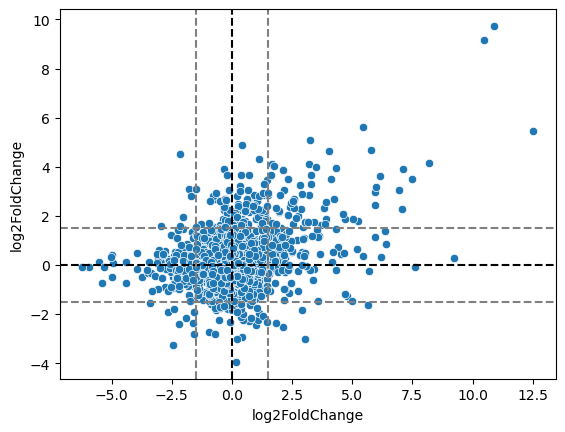

In [52]:
sns.scatterplot(x =trimmed_tomato_ortho['log2FoldChange'], y = trimmed_arabi_ortho['log2FoldChange'], )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")

Text(0, 0.5, 'Genewise log2-fold change in \n Sorghum Drought')

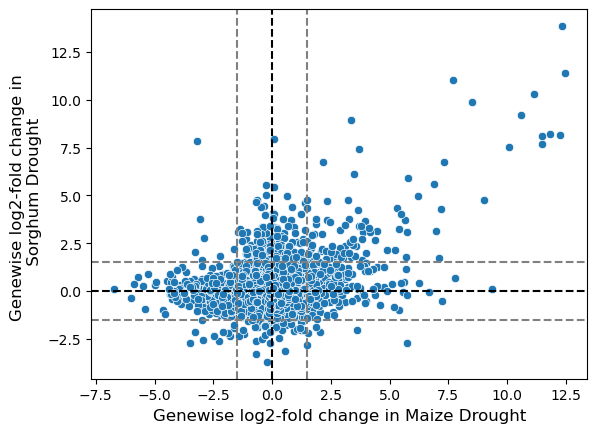

In [53]:
sns.scatterplot(x =tomato_genes_trimmed['log2FoldChange'], y = arabi_genes_trimmed['log2FoldChange'])
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.xlabel("Genewise log2-fold change in Maize Drought", fontsize = 12)
plt.ylabel("Genewise log2-fold change in \n Sorghum Drought", fontsize = 12)

In [54]:
new_merged_result = pd.DataFrame(data = zip(tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']), columns = ['Tomato','Arabi'])

all_over_1 = new_merged_result.loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]
all_under_1 = new_merged_result.loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_bottom = new_merged_result.loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_top = new_merged_result.loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]

In [55]:
new_merged_result['Classification'] = 'Non-substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]= 'Substantial'

/tmp/ipykernel_1190780/1856289886.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
/tmp/ipykernel_1190780/1856289886.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
/tmp/ipykernel_1190780/1856289886.py:4: SettingWithCopyWarning: 
A value is t

Text(0, 0.5, 'Genewise log2-fold change in Sorghum Drought')

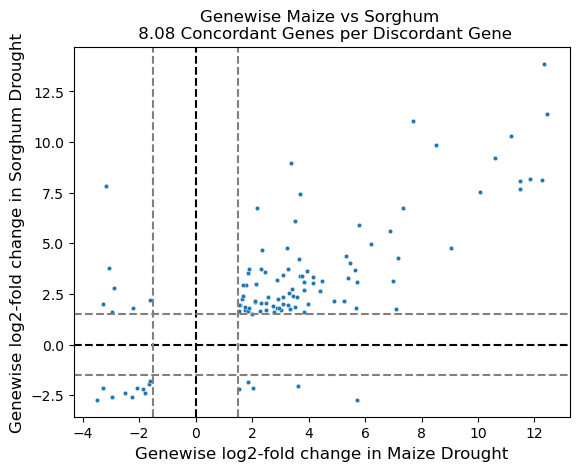

In [59]:
sns.scatterplot(data = new_merged_result.loc[new_merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 10 )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.title('Genewise Maize vs Sorghum \n 8.08 Concordant Genes per Discordant Gene')
plt.xlabel("Genewise log2-fold change in Maize Drought", fontsize = 12)
plt.ylabel("Genewise log2-fold change in Sorghum Drought", fontsize = 12)

In [57]:
discord_ratio = (len(all_over_1)+len(all_under_1))/(len(discord_bottom)+len(discord_top))
discord_ratio

8.083333333333334

In [342]:
all_over_1

,Tomato,Arabi
128,5.420722,2.289623
163,2.688214,1.658393
165,1.529409,1.995355
351,6.788676,2.372646
582,7.428141,2.349108
660,4.131078,2.303250
847,4.748212,2.510446
968,5.096113,2.105806
1064,3.039029,1.728921
1218,2.317202,3.015622


In [343]:
all_under_1

,Tomato,Arabi
1302,-1.546548,-1.996698
3401,-1.570759,-1.713524
4504,-1.584948,-4.405051
4944,-5.482556,-1.861803
5162,-1.628072,-2.431291


In [344]:
merged_result

,Tomato,Arabi
0,-0.145039,0.054831
1,-0.023699,-0.092506
2,0.074602,-0.769619
3,-0.647447,-0.563822
4,-0.407818,-0.445230
...,...,...
3199,2.262803,0.036704
3200,0.376672,0.168016
3201,0.401132,0.728854
3202,-0.146726,-0.288193


In [345]:
merged_result = pd.DataFrame(data = zip(tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']), columns = ['Tomato','Arabi'])

pos_thresh = 0
neg_thresh = 0
tomato_any_change = merged_result.loc[(merged_result['Tomato']>pos_thresh)|(merged_result['Tomato']<neg_thresh)]
tomato_concordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']>pos_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']<neg_thresh))]
tomato_disconcordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']<neg_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']>pos_thresh))]
percent_concordant_tomato = len(tomato_concordant_change)/len(tomato_any_change)
percent_non_discord_tomato = len(tomato_concordant_change)/(len(tomato_concordant_change+tomato_disconcordant_change))
print(percent_concordant_tomato)
print(percent_non_discord_tomato)


arabi_any_change = merged_result.loc[(merged_result['Arabi']>pos_thresh)|(merged_result['Arabi']<neg_thresh)]
arabi_concordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']>pos_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']<neg_thresh))]
arabi_disconcordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']<neg_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']>pos_thresh))]

percent_concordant_arabi = len(arabi_concordant_change)/len(arabi_any_change)
percent_non_discord_arabi = len(arabi_concordant_change)/(len(arabi_concordant_change+arabi_disconcordant_change))

print(percent_concordant_arabi)
print(percent_non_discord_arabi)

0.6387687188019967
0.6387687188019967
0.6387687188019967
0.6387687188019967


In [346]:
stats.spearmanr(a=tomato_genes_trimmed['log2FoldChange'], b = arabi_genes_trimmed['log2FoldChange'] )

SignificanceResult(statistic=0.3778838983240342, pvalue=2.6260518647079396e-203)

In [347]:
down = tomato_genes_trimmed[
    (tomato_genes_trimmed["log2FoldChange"] <= -2) & (tomato_genes_trimmed["padj"] <= 0.001)
]
up = tomato_genes_trimmed[
    (tomato_genes_trimmed["log2FoldChange"] >= 2) & (tomato_genes_trimmed["padj"] <= 0.001)
]
down_arabi = arabi_genes_trimmed[
    (arabi_genes_trimmed["log2FoldChange"] <= -2)
    & (arabi_genes_trimmed["padj"] <= 0.001)
]
up_arabi = arabi_genes_trimmed[
    (arabi_genes_trimmed["log2FoldChange"] >= 2) & (arabi_genes_trimmed["padj"] <= 0.001)
]

In [348]:
down_arabi_ortho = trimmed_arabi_ortho[
    (trimmed_arabi_ortho["log2FoldChange"] <= -2)
    & (trimmed_arabi_ortho["padj"] <= 0.001)
]
up_arabi_ortho = trimmed_arabi_ortho[
    (trimmed_arabi_ortho["log2FoldChange"] >= 2) & (trimmed_arabi_ortho["padj"] <= 0.001)]

down_ortho = trimmed_tomato_ortho[
    (trimmed_tomato_ortho["log2FoldChange"] <= -2) & (trimmed_tomato_ortho["padj"] <= 0.001)
]
up_ortho = trimmed_tomato_ortho[
    (trimmed_tomato_ortho["log2FoldChange"] >= 2) & (trimmed_tomato_ortho["padj"] <= 0.001)
]

In [349]:
len(up_arabi_ortho.merge(how = "inner", right_index = True, left_index= True, right = up_ortho))

5

In [350]:
up_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
114446at3193,1241.209942,3.515908,0.459146,7.657494,1.895955e-14,3.277839e-13
118011at3193,572.664338,2.646269,0.254130,10.413035,2.162169e-25,1.102920e-23
118239at3193,218.445035,2.275324,0.171891,13.236980,5.366364e-40,6.143890e-38
118532at3193,1725.105212,2.161990,0.139590,15.488117,4.173376e-54,1.023868e-51
127999at3193,39.111363,2.056699,0.405571,5.071118,3.954849e-07,2.217125e-06
136845at3193,242.212243,2.145751,0.298576,7.186620,6.641495e-13,9.452205e-12
137296at3193,707.220252,2.480940,0.193344,12.831742,1.088883e-37,1.121985e-35
138520at3193,44.488378,4.133091,0.588411,7.024155,2.153657e-12,2.760110e-11
139009at3193,99.410629,2.081851,0.330890,6.291672,3.140650e-10,2.958068e-09
139101at3193,78.287068,2.997948,0.494597,6.061394,1.349466e-09,1.164564e-08


In [351]:
up_arabi_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
137296at3193,2161.067885,2.174250,0.528502,4.113983,3.888909e-05,5.491535e-04
138520at3193,76.412410,2.153709,0.393055,5.479408,4.267515e-08,1.911330e-06
402643at3193,166.541104,2.019380,0.352363,5.730967,9.985962e-09,5.466390e-07
404029at3193,194.154600,2.164346,0.350151,6.181175,6.362634e-10,5.037842e-08
649605at3193,47.270308,2.015115,0.408406,4.934102,8.052030e-07,2.190350e-05
685441at3193,81.660743,2.091774,0.416022,5.028042,4.955136e-07,1.445465e-05


In [352]:
up

,sorghum Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol
100,LOC8079693,195.258840,2.983458,0.416281,7.166938,7.669375e-13,1.113223e-11,Zm00001d034723
128,LOC8057046,2520.801630,5.420722,0.532738,10.175209,2.558510e-24,1.155618e-22,Zm00001d034643
163,LOC8057096,41.640932,2.688214,0.455019,5.907911,3.464740e-09,3.055697e-08,Zm00001d034571
304,LOC8060482,183.413908,3.368102,0.296143,11.373238,5.683920e-30,3.862100e-28,Zm00001d033990
319,LOC110436814,41370.139495,2.435272,0.166060,14.664978,1.080524e-48,2.059321e-46,Zm00001d033931
...,...,...,...,...,...,...,...,...
5726,LOC8070713,1006.526721,2.215971,0.333194,6.650688,2.917258e-11,3.443422e-10,Zm00001d045392
5747,LOC8071335,1115.939142,2.910148,0.192626,15.107733,1.440095e-51,3.246030e-49,Zm00001d045311
5759,LOC8076148,63.523609,2.440673,0.484010,5.042613,4.592178e-07,2.807768e-06,Zm00001d045204
5776,LOC8065428,25.333567,3.370250,0.568750,5.925710,3.109504e-09,2.760053e-08,Zm00001d037080


In [353]:
up_arabi

,index,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol,sorghum Symbol
128,9124,3100.928023,2.289623,0.461379,4.962561,6.956980e-07,2.118509e-05,Zm00001d034643,LOC8057046
964,5026,2995.168619,2.039980,0.150657,13.540539,9.012488e-42,1.756444e-37,Zm00001d032293,LOC8080108
968,48187,94.957402,2.105806,0.487992,4.315252,1.594213e-05,2.832235e-04,Zm00001d029349,LOC8080751
1271,14949,497.115989,3.143004,0.753548,4.170939,3.033474e-05,4.760014e-04,Zm00001d028408,LOC8054347
1842,38483,198.980996,2.434358,0.367586,6.622557,3.530374e-11,4.169907e-09,Zm00001d005283,LOC8062599
2523,10803,4971.656556,2.025416,0.276492,7.325419,2.381541e-13,4.945837e-11,Zm00001d039315,LOC8081371
2591,13898,4238.575944,2.140743,0.519352,4.121947,3.756841e-05,5.671346e-04,Zm00001d039566,LOC8078754
2609,37520,47.242209,2.009489,0.416134,4.828946,1.372575e-06,3.794341e-05,Zm00001d039634,LOC8078789
2665,32132,972.246781,3.103060,0.639684,4.850928,1.228853e-06,3.460856e-05,Zm00001d039942,LOC8061349
2977,68022,552.870627,2.066635,0.272540,7.582869,3.379950e-14,9.541208e-12,Zm00001d044124,LOC8058201


In [354]:
up_arabi.merge(how = "inner", on = 'arabidopsis Symbol', right = up)

KeyError: 'arabidopsis Symbol'